Ноутбук служит основой для изучения, однако многое нужно будет поискать и почитать самостоятельно. В некоторых заданиях (да и вообще по теме) это дз будет опираться на материал пары.
***

В этом домашнем задании мы (вы) поговорим о, как не странно, **визуализации**. Но говорить о ней надо на каком-то материале. В этот раз немного отдохнем от данных и сами их посоздаем, по моделируем (ну почти).

Я уверена, что вы уже так или иначе владеете кодовыми библиотеками `matplotlib` и `seaborn`, поэтому просто напомню базовый чек-лист из прошлого задания про построение графиков.

- [x] должно быть **понятно**, что изображено на графике;  
- [x] должны присутствовать **названия осей** (за исключением, когда это очевидно);  
- [x] если на графике присутствуют разные данные, то должна быть **легенда**.

В этом дз мы скорее изучим какие-то неочевидные и/или прикольные интересности, чем пройдемся по базовым вещам.  *УРА ИНТЕРЕСНОСТИ*
Для знакомства с базой вот вам [мой любимый простой гайд](https://skillbox.ru/media/code/biblioteka-matplotlib-dlya-postroeniya-grafikov/),
[документация](https://matplotlib.org/3.6.2/users/index.html)
и еще немного материала: [доступен просто так](https://devpractice.ru/matplotlib-lesson-1-quick-start-guide/),
[доступен не просто так](https://pythonworld.ru/novosti-mira-python/scientific-graphics-in-python.html).

# Задание 1: Дискретная непрерывность (2 pt)

Вы знаете, что при $n \rightarrow \infty$ **геометрическое распределение** стремится к **экспоненциальному**
$$\frac{1}{n} Geom\Bigg(\frac{\lambda}{n}\Bigg) \rightarrow Exp(\lambda).$$
Давайте графически это подтвердим!

Для этого нам понадобится:
- [ ] умение [генерировать](####Генерация) случайные величины;
- [ ] умение получать [теоретическую](####Теоретическое-в-коде) плотность;
- [ ] умение [строить](####Построение-графиков) гистограммы;
- [ ] умение [сглаживать](####Сглаживание) данные;
- [ ] умение строить [несколько](####Несколько-графиков) графиков в одной фигуре

*Много теории только тут, дальше столько не будет. Не пропускайте ее, пожалуйста, ну или хотя бы обращайте внимание на выделенное*

#### Генерация

В Python существует **два основных подхода к генерации случайных величин** из различных распределений:  
* `numpy.random`
* `scipy.stats`

В первом случае генерация происходит "на прямую", а во втором как получение выборки конкретной случайной велечины (как метод объекта). Работает `scipy.stats` чуть медленнее, однако это некритично для небольших объемов и точечных вызовов.

Генерация в `numpy.random` происходит через вызов конкретных методов для каждого распределения: `np.random.uniform(a, b, size)`, `np.random.normal(loc, scale, size)`, `np.random.exponential(scale, size)` и так далее.

<div class="alert alert-danger">
<b>ВАЖНО:</b> в экспоненциальном распределении scale = 1/$\lambda$, а не $\lambda$.
</div>

Подробнее как всегда читайте в [документации](https://numpy.org/doc/2.1/reference/random/generator.html), но в этом задании лучше использовать `scipy.stats`.

При этом в обоих случаях не забывайте **фиксировать** `np.random.seed(42)` для **воспроизводимости** результатов!
***

Логика работы со случайными величинами в `scipy.stats` всегда примерно одинаковая:

```python
from scipy import stats

# Создание случайной величины как объекта
xi = stats.norm(loc=0, scale=1)

# Генерация выборки
samples = xi.rvs(size=1000)

pdf_values = xi.pdf(x)      # Плотность вероятности
cdf_values = xi.cdf(x)      # Функция распределения
ppf_values = xi.ppf(q)      # Квантильная функция (обратная CDF)
mean = xi.mean()            # Математическое ожидание
var = xi.var()              # Дисперсия
...
```

При этом в этом модуле реализовано оооооочень много разных распределений!  
| Распределение | Класс | Параметры |
| :------------ | :---- | :-------- |
| **Равномерное** $U(a,b)$ | `stats.uniform` | `loc=a`, `scale=b-a` |
| **Нормальное** $N(\mu,\sigma^2)$ | `stats.norm` | `loc`=$\mu$, `scale`=$\sigma$ |
| **Биномиальное** $Bin(n,p)$ | `stats.binom` | `n`, `p` |
| **Экспоненциальное** $Exp(\lambda)$ | `stats.expon` | `scale`=1/$\lambda$ |
| **Пуассоновское** $Pois(\lambda)$ | `stats.poisson` | `mu`=$\lambda$ |
| **Геометрическое** $Geom(p)$ | `stats.geom` | `p` |
| **Гамма** $Gamma(\alpha,\beta)$ | `stats.gamma` | `a`=$\alpha$, `scale`=1/$\beta$` |
| **Бета** $Beta(\alpha,\beta)$ | `stats.beta` | `a`=$\alpha$, `b`=$\beta$` |
| **Отрицательное биномиальное** $NegBin(r,p)$ | `stats.nbinom` | `n=r`, `p` |
| **Бета-биномиальное** | `stats.betabinom` | `n`, `a`=$\alpha$, `b`=$\beta$` |
| **Стьюдента** $T(d)$ | `stats.t` | `loc=a`, `df=d` |

Как всегда подробнее читайте в [документации](https://docs.scipy.org/doc/scipy/reference/stats.html).

#### Теоретическое в коде


Как было показано ранее из объектов класса распределения можно получать теоретические вещи:
- функцию распределения,
- плотность,
- ожидание,
- дисперсию и так далее
```python
xi = stats.norm(loc=0, scale=1)
cdf_values = xi.cdf(x)
```

Но для дискретных распределений нужно использовать вероятностную массовую функцию (**PMF**), а не плотность (**PDF**). А также их можно получать не от объекта класса, а **через методы сразу**:
```python
binom_pmf = stats.binom.pmf(k, n=100, p=0.05)
```
Для визуализации такого можно использовать `plt.stem()`.

#### Построение графиков

Для построения графиков, очевидно, понадобится `matplotlib.pyplot` или `seaborn`.

Если мы работаем с распределениями, то нам точно понадобятся следующие графики:

| Тип графика | Когда использовать | Пример |
| :---------- | :----------------- | :----- |
| **Гистограмма** (`plt.hist`) | Для отображения эмпирических данных | Приближенная визуализация распределения |
| **Столбчатая диаграмма** (`plt.bar`) | Для дискретных распределений (точное совпадение с целыми значениями) | Визуализация `Pois(λ)` или `Bin(n, p)` без искажения дискретной природы |
| **Линейный график плотности** (`plt.plot`) | Для непрерывных распределений или сглаженных оценок | Наложение теоретической кривой на гистограмму |
| **Точечный график с линиями** (`plt.plot(..., 'o-')`) | Для дискретных распределений при сравнении с теорией | Отображение `pmf` дискретного распределения поверх гистограммы |

**Параметры**

Для лучшей и более понятной визуализации важно уметь работать со следующими параметрами:

| Параметр | За что отвечает | Когда использовать | Пример |
|----------|----------------|-------------------|--------|
| `density=True` | Нормализует гистограмму так, чтобы **площадь = 1** | **Всегда** при сравнении с теоретической плотностью/`pmf` | `plt.hist(data, bins=30, density=True)` |
| `bins` | Количество или границы интервалов гистограммы | Для дискретных распределений: `bins=range(min, max+1)` | `plt.hist(data, bins=range(0, 20))` |
| `alpha` | Прозрачность элемента (0.0–1.0) | При наложении нескольких графиков для видимости перекрытия | `plt.hist(..., alpha=0.6)` |
| `color` / `edgecolor` | Цвет заливки и границ | Для визуального разделения компонентов смеси | `color='skyblue', edgecolor='black'` |
| `label` + `plt.legend()` | Подпись элемента и отображение легенды | При сравнении нескольких распределений на одном графике | `label='Эмпирические данные'` |
| `ax.grid(True, alpha=0.3)` | Добавление сетки | **Всегда** — улучшает читаемость и оценку значений | `ax.grid(True, linestyle='--', alpha=0.3)` |
| `ax.set_xlabel()` / `ax.set_ylabel()` | Подписи осей | **Всегда** — без подписей график непонятен | `ax.set_xlabel('Время между покупками (часы)')` |
| `ax.set_title()` | Заголовок графика | Для краткого описания содержания | `ax.set_title('Сходимость Bin(...) -> Pois(...)')` |
| `ax.annotate()` | Текстовая аннотация со стрелкой | Для выделения ключевых точек (максимумы, пороги) | См. пример ниже |
| `plt.tight_layout()` | Автоматическая настройка отступов | **Перед сохранением** — предотвращает обрезку элементов | `plt.tight_layout()` |
| `dpi` в `savefig()` | Разрешение изображения | Для отчётов: `dpi=150`, для публикаций: `dpi=300` | `plt.savefig('graph.png', dpi=150)` |



Для сравнения данных нам понадобится именно гистограммы (нормированные диаграммы), этого можно добиться при помощи параметра `density=True`: она автоматически нормируется так, чтобы *площадь под диаграммой равнялась 1*.

Подробнее в [документации](https://matplotlib.org/stable/api/pyplot_summary.html).

#### Сглаживание

Когда мы работаем с гистограммой, мы работаем с кусочным объектом, который **зависит от разбиения** (бинов). Поэтому иногда полезно видеть **сглаженную** кривую, которая лучше показывает форму распределения.

Для этой цели можно использовать **ядерное сглаживание** `gaussian_kd`:
* Ядро сглаживания строит гладкую кривую через данные
* Параметр `bw_method` регулирует "гладкость" (по умолчанию — оптимальный)
* Для малых выборок используйте `kde = gaussian_kde(data, bw_method=0.5)`
```python
kde = gaussian_kde(data)
x = np.linspace(min(data), max(data), 1000)
plt.plot(x, kde(x))
```

**Как выбрать** параметр `bw_method`?

```python
# Слишком гладко (теряем детали)
kde1 = gaussian_kde(samples, bw_method=2.0)

# Оптимально (по умолчанию)
kde2 = gaussian_kde(samples, bw_method='scott')  # или 'silverman'

# Слишком "рвано" (шум вместо сигнала)
kde3 = gaussian_kde(samples, bw_method=0.1)
```

<div class="alert alert-danger">
<b>ВАЖНО:</b> Сглаживание может ввести в заблуждение — создать иллюзию непрерывности.
</div>

Подробнее угадайте где? В [документации](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.gaussian_kde.html)!

#### Несколько графиков

Когда нужно сравнить распределения при разных параметрах или показать эволюцию процесса, **одного графика недостаточно**. В этом случае используем **сетку графиков (subplots)**.

**Базовый синтаксис**: `plt.subplots()`

```python
import matplotlib.pyplot as plt

# Создание сетки 2x3 (2 строки, 3 столбца)
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 8))
# axes — это двумерный массив объектов осей

# Доступ к отдельным графикам
ax_top_left = axes[0, 0]    # верхний левый
ax_bottom_right = axes[1, 2]  # нижний правый

# Если нужен одномерный массив (удобнее для циклов)
axes_flat = axes.flatten()  # превращает (2,3) → (6,)
```

**Ключевые параметры**:

| Параметр | За что отвечает | Пример |
| :------- | :-------------- | :----- |
| `nrows`, `ncols` | Количество строк и столбцов |  `plt.subplots(2, 3)` -> сетка 2x3 |
| `figsize=(w, h)` | Размер всей фигуры в дюймах | `figsize=(14, 6)` — широкая фигура для горизонтального сравнения |
| `sharex=True/False` | Общая ось X для всех графиков | При сравнении распределений с одинаковым диапазоном значений |
| `sharey=True/False` | Общая ось Y для всех графиков | При сравнении плотностей или диаграмм с одинаковым масштабом |
| `squeeze=True` *(по умолчанию)* | Упрощает форму массива `axes` | При `nrows=1`, `ncols=1` возвращает один объект `ax`, а не массив 1x1 |
| `gridspec_kw` | Тонкая настройка размеров ячеек | `gridspec_kw={'width_ratios': [2, 1]}` — первый график в 2 раза шире второго |

Ну и подробнее в любимой [документации](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.subplots.html).

***
## Задание (2 pt)

Изучите приближение геометрического распределения к экспоненциальному через визуализацию.

**Постройте сетку 2×2 графиков для разных значений $n$ (20, 50, 100, 1000) при фиксированном значении $\lambda=2$**  
**На каждом графике** отобразите:
- гистограмму выборки из $\frac{1}{n} Geom\big(\frac{\lambda}{n}\big)$,
- теоретическую плотность соответствующего экспоненциального,
- сглаженную плотность из данных,
- легенду с нужными значениями.

Для этого используйте нужные виды графиков, цветовую дифференциацию, правильные подписи и вообще _**всю красоту**_.

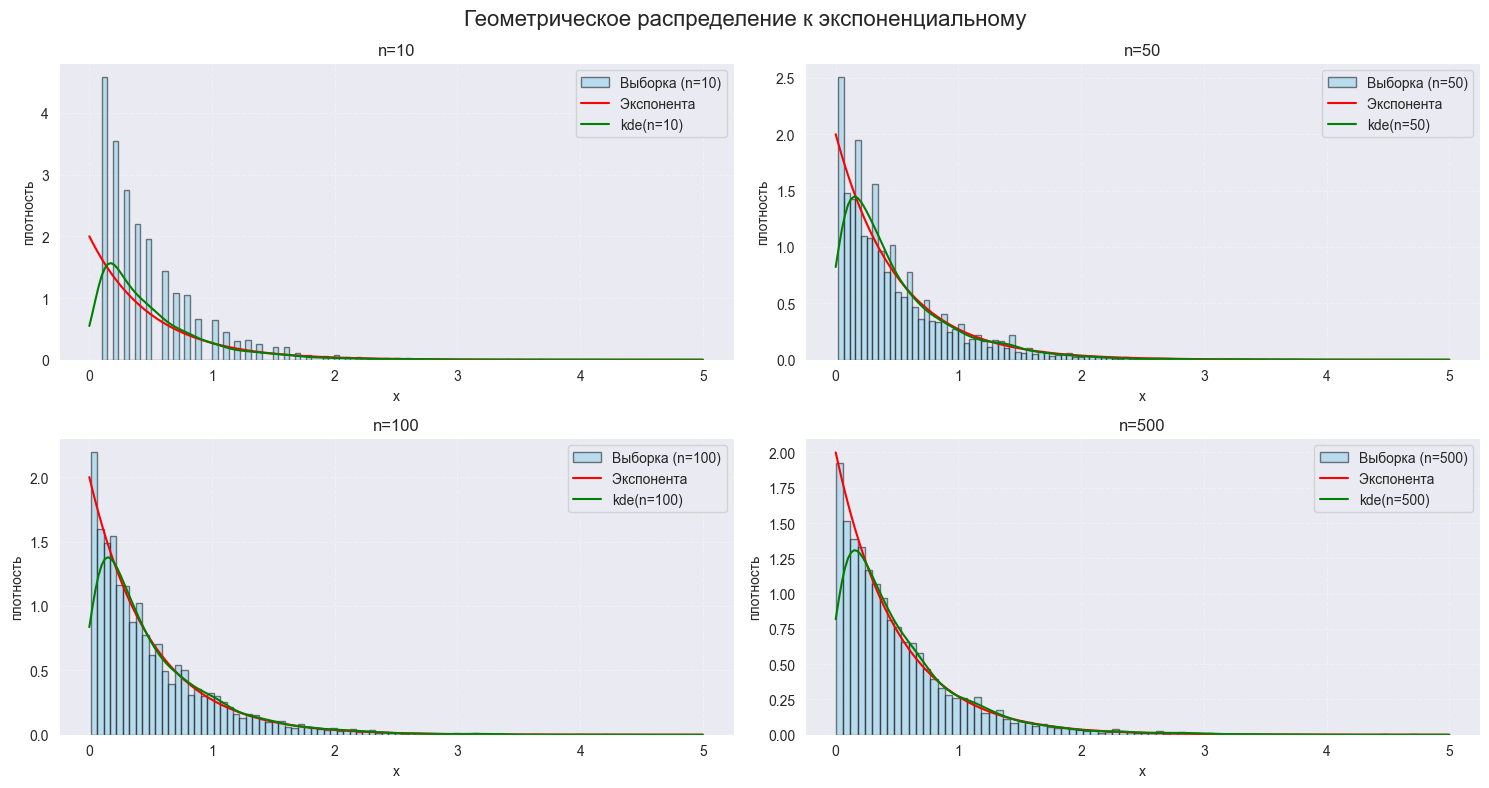

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import gaussian_kde
import seaborn as sns
import pandas as pd

np.random.seed(42)
lambda_param = 2.0
n_values = [10, 50, 100, 500]
n_samples = 5000  # размер выборки для каждого n

# Создайте сетку 2x2
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(15, 8))
axes = axes.flatten()

for idx, n in enumerate(n_values):
    ax = axes[idx]
    
    # Генерируем выборку
    geom = stats.geom.rvs(p=lambda_param/n, size=n_samples) / n
    
    # Рисуем гистограмму   
    ax.hist(geom, density=True, bins=80, alpha=0.5, color='skyblue', edgecolor='black', label=f'Выборка (n={n})')    
    x_vals = np.linspace(0, 5, 200)
    exp_pdf = stats.expon.pdf(x_vals, scale=1 / lambda_param) 
    ax.plot(x_vals, exp_pdf, color='red', label=f'Экспонента ')
    
    kde = gaussian_kde(geom, bw_method=0.2)
    
    ax.plot(x_vals, kde(x_vals), color='green', label=f'kde(n={n})')
    
    ax.set_xlabel('x')
    ax.set_ylabel('плотность')
    ax.set_title(f'n={n}')
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.3)

fig.suptitle('Геометрическое распределение к экспоненциальному', fontsize=16)
plt.tight_layout()
# plt.savefig('task1_geometric_exponential.png', dpi=150, bbox_inches='tight') МОЖНО СОХРАНИТЬ, А НЕ ПРОСТО ВЫВЕСТИ
plt.show()

кривая KDE плохо себя ведёт (негодяйка). Мне было неочевидно, почему она вблизи нуля ведёт себя не так, как должна, сбивает с толку. Как будто гистограммы было бы достаточно для понимания. Пообщался с коллегами, выяснил, что это не я ошибся:

> Метод Гауссова ядра «не знает», что наши данные не могут быть меньше нуля. 
>Когда ядро центрируется на наблюдении, близком к нулю (например, 0.1), оно симметрично «размазывает» вероятность и влево 
>(в область отрицательных значений), и вправо. В результате часть массы уходит в недопустимую область (x < 0)
>Чтобы общая площадь под кривой осталась равной 1, оценка вблизи нуля автоматически завышается, но форма всё равно искажается: пик смещается вправо, а слева от нуля плотность обрезается (мы её не видим на графике, но вклад в нормировку она даёт).

Ну мне сильно захотелось проучить негодяйку и заставить её работать нормально.
Как я понял, нужно:
- отразить данные относительно нуля
- построить KDE на симметричной выборке
- Удвоить плотность
- пихнуть на график

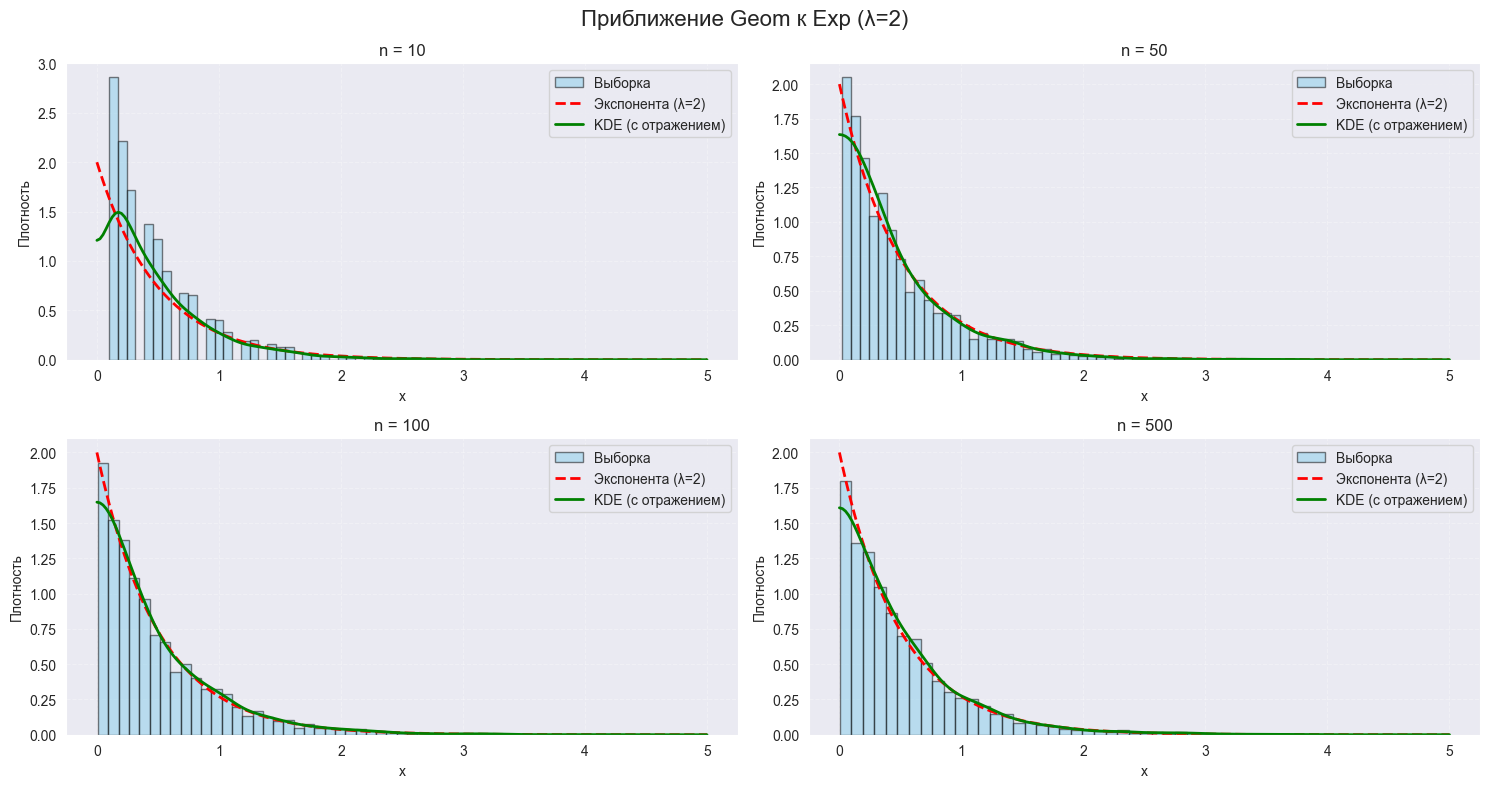

In [2]:
np.random.seed(42)
lambda_param = 2.0
n_values = [10, 50, 100, 500]
n_samples = 5000

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(15, 8))
axes = axes.flatten()

for idx, n in enumerate(n_values):
    ax = axes[idx]
    geom = stats.geom.rvs(p=lambda_param/n, size=n_samples) / n
    ax.hist(geom, bins=50, density=True, alpha=0.5, color='skyblue', edgecolor='black', label='Выборка')
    
    x_vals = np.linspace(0, 5, 200)
    exp_pdf = stats.expon.pdf(x_vals, scale=1/lambda_param)
    ax.plot(x_vals, exp_pdf, 'r--', linewidth=2, label='Экспонента (λ=2)')
    
    
    reflected = np.concatenate([geom, -geom])# отражаем
    kde_ref = gaussian_kde(reflected) # KDE на симметричной выборке
    kde_vals = 2 * kde_ref(x_vals)# удваиваем для положительной полуоси
    ax.plot(x_vals, kde_vals, 'g-', linewidth=2, label='KDE (с отражением)')
    
    ax.set_xlabel('x')
    ax.set_ylabel('Плотность')
    ax.set_title(f'n = {n}')
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.3)

fig.suptitle('Приближение Geom к Exp (λ=2)', fontsize=16)
plt.tight_layout()
plt.show()

ГОООООООООООООООООЛ, стало лучше!

# Задание 2: Не детские смеси (3 pt)

В этом задании мы повизуализируем смеси. Все нужые **ссылки и прочее уже были даны ранее**, добавлю только несколько фич:

| Фича | Метод | Зачем использовать |
| :--- | :---- | :----------------- |
| **Аннотации со стрелками** | `ax.annotate()` | Выделение ключевых точек графика с визуальной связью между текстом и объектом |
| **Текстовые блоки с фоном** | `ax.text()` + `bbox` | Добавление поясняющего текста с выделением фона для читаемости |
| **Вертикальные/горизонтальные линии** | `ax.axvline()`, `ax.axhline()` | Выделение порогов, средних значений, квантилей |
| **Заливка областей** | `ax.fill_between()`, `axvspan()` | Визуализация доверительных интервалов, выделение зон интереса |
| **Настройка шрифтов** | `fontdict`, `fontsize` | Единый стиль оформления текстовых элементов |
| **Стили линий и маркеров** | `linestyle`, `marker` | Различение нескольких кривых без цвета |

У всего этого куча интересных параметров, за ними идите в [ДО](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.annotate.html)
[КУ](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.text.html)
[МЕН](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.axvline.html)
[ТА](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.fill_between.html)
[ЦИ](https://matplotlib.org/stable/gallery/text_labels_and_annotations/accented_text.html)
[Ю](https://matplotlib.org/stable/gallery/text_labels_and_annotations/annotation_basic.html)!

## «Теоретическое» задание (1,5 pt)

Смоделируйте **загрязнённое нормальное распределение**, которое можно встретить, например, в ситуации, когда есть основная группа пользователей и малая часть "активных"

$$(1 - \varepsilon) \cdot N(\mu, \sigma^2) + \varepsilon \cdot N(\mu, \alpha\sigma^2).$$

Ваша **необходимо**:
1. Сгенерировать **выборку** из загрязненного нормального распределения с параметрами:
   - $\mu = 0$, $\sigma =  1$
   - $\varepsilon = 0.15$ *(вот тут появляется Бернулли)*
   - $\alpha = 4$
2. Построить **один график** со следующими элементами:
   - Гистограмма эмпирических данных (серый цвет, `alpha=0.6`)
   - Теоретическая плотность основного компонента (синяя линия, `alpha=0.7`)
   - Теоретическая плотность загрязняющего компонента (красная линия, `alpha=0.7`)
   - Полная теоретическая плотность смеси (чёрная пунктирная линия, толщина 2.5)
   - Сравнение с "чистым" нормальным распределением (фиолетовая штрихпунктирная линия) — *чтобы показать, как загрязнение искажает форму*
   - Аннотация со стрелкой, указывающая на "тяжёлые хвосты" от загрязняющего компонента
   - Текстовый блок с параметрами смеси и интерпретацией (используйте `bbox`)

В этом задании для генерации используем `numpy.random`.

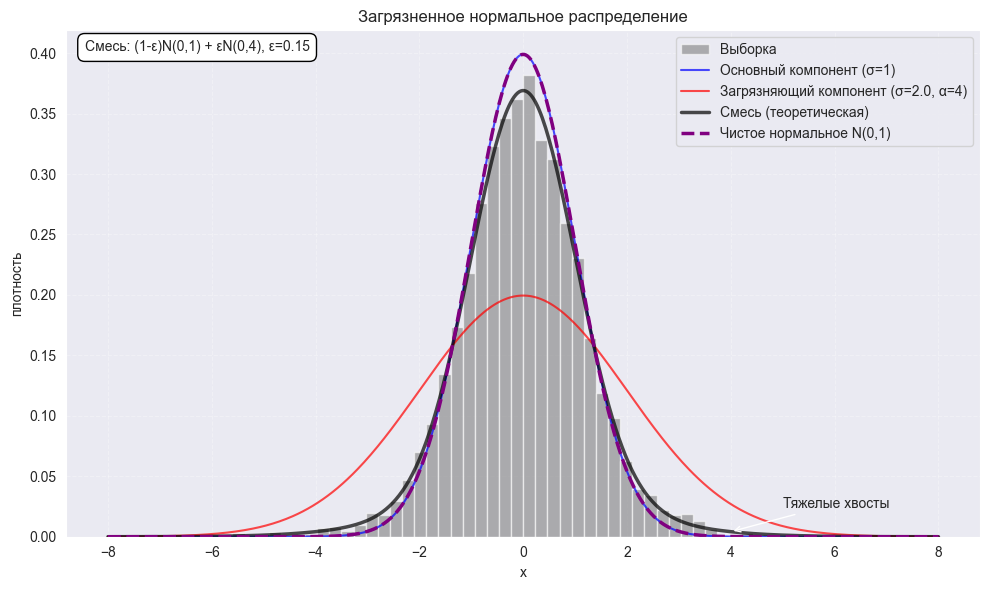

In [3]:
np.random.seed(42)

mu = 0
sigma = 1
epsilon = 0.15
alpha = 4
n_samples = 5000

# Генерация смеси
is_contaminated = np.random.binomial(1, epsilon, n_samples)
main_component = np.random.normal(0,1, n_samples)
contaminated_component = np.random.normal(0, sigma * np.sqrt(alpha), n_samples)
mixture = np.where(is_contaminated == 1, contaminated_component, main_component)

# Создание графика
fig, ax = plt.subplots(figsize=(10, 6))

# Гистограмма
ax.hist(mixture, density=True, bins=50, alpha=0.6, color='gray', label='Выборка')

# Теоретические компоненты
x_vals = np.linspace(-8, 8, 500)
main_pdf = stats.norm.pdf(x_vals, mu, sigma)
ax.plot(x_vals, main_pdf, color='blue', alpha=0.7, label= f'Основный компонент (σ={sigma})')

contaminated_pdf = stats.norm.pdf(x_vals, 0, np.sqrt(alpha) * sigma)
ax.plot(x_vals, contaminated_pdf, color='red', alpha=0.7, label= f'Загрязняющий компонент (σ={sigma * np.sqrt(alpha)}, α={alpha})')

mixture_pdf = (1-epsilon) * main_pdf + epsilon * contaminated_pdf
ax.plot(x_vals, mixture_pdf, color='black', alpha=0.7, linewidth=2.5, label='Смесь (теоретическая)')

# Чистое нормальное для сравнения
pure_normal_pdf = stats.norm.pdf(x_vals, mu, sigma)
ax.plot(x_vals, pure_normal_pdf, color='purple', linestyle='--', linewidth=2.5, label='Чистое нормальное N(0,1)')

# Аннотация на тяжёлые хвосты
x = 4
#y = 0.1 Тут сработала великая теорема подбора. Ладно, шучу, давайте вычислим
y = (1 - epsilon) * stats.norm.pdf(x, mu, sigma) + epsilon * stats.norm.pdf(x, mu, sigma * np.sqrt(alpha)) 
ax.annotate('Тяжелые хвосты',xy=(x,y), xytext=(x+1, y+0.02), arrowprops=dict(arrowstyle='->'))

# Текстовый блок с интерпретацией
interpretation_text = ('Смесь: (1-ε)N(0,1) + εN(0,4), ε=0.15')
ax.text(0.02, 0.98, interpretation_text, transform=ax.transAxes, 
        verticalalignment='top', bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.5'))

# Оформление
ax.set_xlabel('x')
ax.set_ylabel('плотность')
ax.set_title('Загрязненное нормальное распределение')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

## Практическое задание (1,5 pt)

В этом задании мы все же поработаем с данными, но с теми, с которыми вы уже знакомы! Будем снова говорить про пингвинчиков)

Вам **необходимо**:
1. Загрузить датасет и удалить строки с пропущенными значениями в столбце `bill_length_mm`
2. Построить **два графика** на **одной фигуре** (сетка 1×2):
   - Левый график: **Общая гистограмма** длины клюва всех пингвинов + наложенные плотности для каждого вида (разные цвета, `alpha=0.6`)
   - Правый график: **Три отдельные гистограммы** по видам (на одном графике для сравнения) с **теоретическими нормальными кривыми**
3. На левом графике добавьте:
   - **Аннотацию со стрелкой на бимодальность** (место между пиками)
   - **Текстовый блок с интерпретацией**: почему общее распределение выглядит как смесь?
   - **Вертикальные линии**, показывающие средние значения для каждого вида
4. На правом графике добавьте:
   - **Легенду** с указанием вида и количества особей
   - **Подпись с выводом**: *какой вид имеет наибольшую вариабельность длины клюва?*

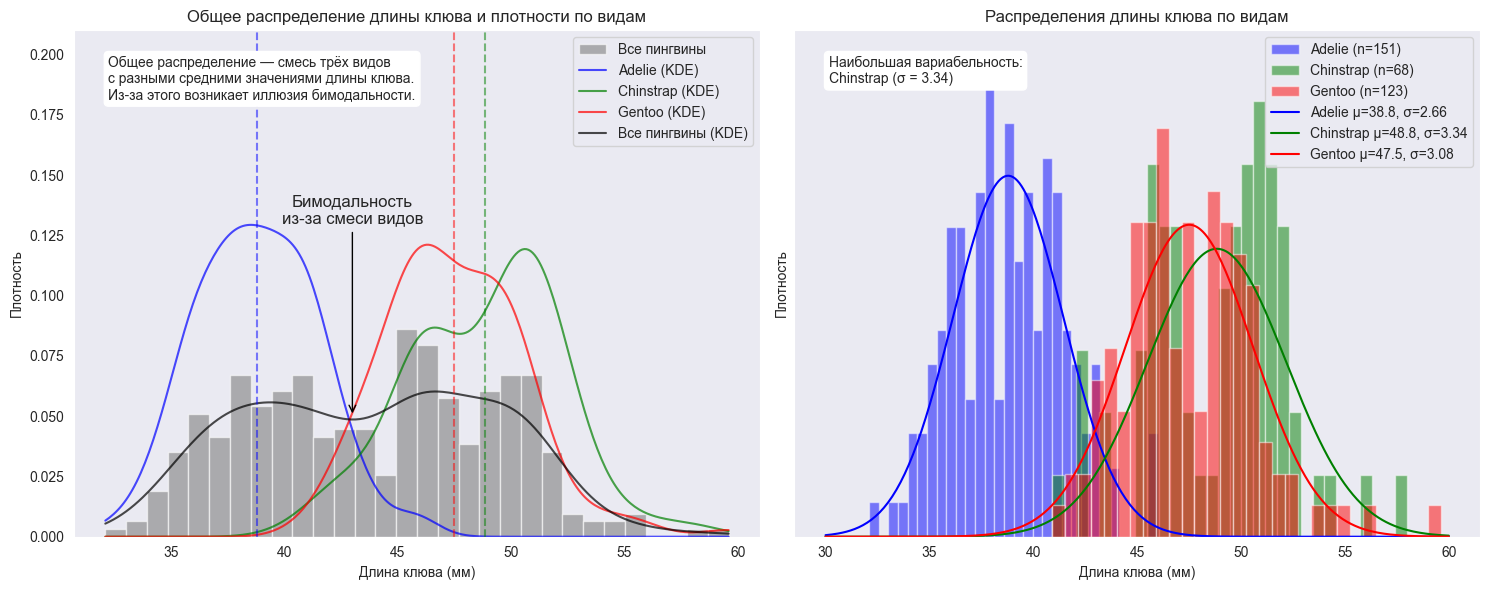

In [4]:
penguins = sns.load_dataset('penguins')
penguins_clean = penguins.dropna(subset=['bill_length_mm'])

adelie = penguins_clean[penguins_clean['species'] == 'Adelie']['bill_length_mm']
chinstrap = penguins_clean[penguins_clean['species'] == 'Chinstrap']['bill_length_mm']
gentoo = penguins_clean[penguins_clean['species'] == 'Gentoo']['bill_length_mm']
all_penguins = penguins_clean['bill_length_mm']

mu_adelie, std_adelie = adelie.mean(), adelie.std()
mu_chinstrap, std_chinstrap = chinstrap.mean(), chinstrap.std()
mu_gentoo, std_gentoo = gentoo.mean(), gentoo.std()


fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 6), sharey=True)
ax1, ax2 = axes

# Левый график: общая смесь
ax1.hist(all_penguins, bins=30, density=True, color='gray', alpha=0.6, label='Все пингвины')
x_range = np.linspace(all_penguins.min(), all_penguins.max(), 300)
kde_adelie = gaussian_kde(adelie)
kde_chinstrap = gaussian_kde(chinstrap)
kde_gentoo = gaussian_kde(gentoo)

ax1.plot(x_range, kde_adelie(x_range), color='blue', alpha=0.7, label='Adelie (KDE)')
ax1.plot(x_range, kde_chinstrap(x_range), color='green', alpha=0.7, label='Chinstrap (KDE)')
ax1.plot(x_range, kde_gentoo(x_range), color='red', alpha=0.7, label='Gentoo (KDE)')

#Захотел добавить общую плотность для наглядности
kde_all = gaussian_kde(all_penguins)
ax1.plot(x_range, kde_all(x_range), color='black', alpha=0.7, label='Все пингвины (KDE)')

# Вертикальные линии средних
ax1.axvline(mu_adelie, color='blue', linestyle='--', alpha=0.5)
ax1.axvline(mu_chinstrap, color='green', linestyle='--', alpha=0.5)
ax1.axvline(mu_gentoo, color='red', linestyle='--', alpha=0.5)

x_annot = 43  # теорема подбора
y_annot = 0.05  # и тут она же
ax1.annotate('Бимодальность\nиз-за смеси видов', xy=(x_annot, y_annot), xytext=(x_annot, y_annot+0.08),
             arrowprops=dict(arrowstyle='->', color='black'), fontsize=12, ha='center')

# Подписи 
ax1.text(0.05, 0.95, 
         'Общее распределение — смесь трёх видов\n'+
          'с разными средними значениями длины клюва.\n'+
          'Из-за этого возникает иллюзия бимодальности.', 
         transform=ax1.transAxes, fontsize=10,verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white'))
ax1.set_xlabel('Длина клюва (мм)')
ax1.set_ylabel('Плотность')
ax1.set_title('Общее распределение длины клюва и плотности по видам')
ax1.legend(loc='upper right')
ax1.grid(False)


# Правый график: гистограммы 
ax2.hist(adelie, bins=30, density=True, color='blue', alpha=0.5, label=f'Adelie (n={len(adelie)})')
ax2.hist(chinstrap, bins=30, density=True, color='green', alpha=0.5, label=f'Chinstrap (n={len(chinstrap)})')
ax2.hist(gentoo, bins=30, density=True, color='red', alpha=0.5, label=f'Gentoo (n={len(gentoo)})')

# Теоретические нормальные кривые на общем диапазоне
x_fit = np.linspace(30, 60, 300)
ax2.plot(x_fit, stats.norm.pdf(x_fit, mu_adelie, std_adelie), 'b-', label=f'Adelie μ={mu_adelie:.1f}, σ={std_adelie:.2f}')
ax2.plot(x_fit, stats.norm.pdf(x_fit, mu_chinstrap, std_chinstrap), 'g-', label=f'Chinstrap μ={mu_chinstrap:.1f}, σ={std_chinstrap:.2f}')
ax2.plot(x_fit, stats.norm.pdf(x_fit, mu_gentoo, std_gentoo), 'r-', label=f'Gentoo μ={mu_gentoo:.1f}, σ={std_gentoo:.2f}')

# Определяем вид с наибольшим std
stds = [std_adelie, std_chinstrap, std_gentoo]
species_names = ['Adelie', 'Chinstrap', 'Gentoo']
max_std_idx = np.argmax(stds)
most_variable = species_names[max_std_idx]
max_std_value = stds[max_std_idx]

# Подписи 
ax2.text(0.05, 0.95, f'Наибольшая вариабельность:\n{most_variable} (σ = {max_std_value:.2f})',
         transform=ax2.transAxes, fontsize=10, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='white'))
ax2.set_xlabel('Длина клюва (мм)')
ax2.set_ylabel('Плотность')
ax2.set_title('Распределения длины клюва по видам')
ax2.legend()
ax2.grid(False)

plt.tight_layout()
plt.show()

# Задание 3: Buy Till You Die (5 pt)

В этом задании мы поработаем с моделью, которая может пригодиться при аналитике реальных процессов. Напоминаю:

> Предположим, что после первой покупки, пользователи ведут себя так:  
> С вероятностью `p` он перестает пользоваться сервисом, а с вероятностью `1 − p` не перестает.
> Тем самым количество покупок имеет распределение `Geom(p)`. Такой способ моделировать «смерть» пользователя называется **Buy Till You Die (BTYD)**  
> Если покупатель не перестал пользоваться сервисом, то следующая покупка происходит через время `Exp(λ)`.
> У каждого пользователя параметры `p` и `λ` свои, и **вариабельность в их значениях** моделируются с помощью `Beta(αp, βp)` для `p` и `Gamma(αλ,βλ)` для `λ`.  
> Получившуюся модель называют **Beta-Geometric/Negative Binomial Distribution (BG/NBD)**.


### Теоретическое задание (1,5 pt)

Пусть в момент последней активности пользователь с вероятностью $p$ ушел, и, стало быть, с вероятностью $1−p$ остался. Если пользователь остался, то его следующая активность случится через время $T$, которое имеет распределение $Exp(q)$.

Выразите через $p$, $q$ и $t$ вероятность того, что **пользователь остался при условии, что он не проявлял активность в течение времени** $t$.

В КАЧЕСТВЕ РЕШЕНИЯ ОЖИДАЕТСЯ ФОРМУЛА И ТО, КАК ВЫ ЕЕ ПОЛУЧИЛИ (С ПОЯСНЕНИЕМ РАССУЖДЕНИЙ)

Пусть событие $A$ - пользователь ушёл. $P(A) = p$.
Пусть событие $B$ - пользователь остался. $P(B) = 1 - p$.
Пусть событие $N$ - активности нет в течение времени $t$.

Если пользователь ушёл, то активности не будет никогда, поэтому $P(N | A) = 1$.
Если пользователь остался, то время до следующей активности распределено экспоненциально с параметром $q$.
Отсутствие активности в течение времени $t$ означает, что это время больше $t$. Вероятность этого: $P(N | B) = e^{-q \cdot t}$.

По формуле полной вероятности:
$P(N) = P(A) \cdot P(N | A) + P(B) \cdot P(N | B) = p \cdot 1 + (1 - p) \cdot e^{-q \cdot t} = p + (1 - p) \cdot e^{-q \cdot t}$.

Тогда условная вероятность того, что пользователь остался, при условии отсутствия активности в течение времени t:

$$P(B | N) = \frac{P(B \cap N)} {P(N)} = \frac{P(B) \cdot P(N | B)} {P(N)} = \frac{(1 - p) \cdot e^{-q \cdot t}} { p + (1 - p) \cdot e^{-q \cdot t}}$$




### Практическое задание (3,5 pt)

Будем использовать публичный датасет `CDNOW` — классический датасет для анализа поведения покупателей (покупки музыки онлайн в 1997-98 годах). Датасет содержит:
- `customer_id` — идентификатор покупателя
- `date` — дата покупки
- `quantity` — количество купленных альбомов
- `value` — сумма покупки в долларах

Ваша задача: **построить график** 2x2, отвечающий на **4 бизнес-вопроса**:

| Подграфик | Вопрос | Требования |
| :-------- | :----- | :--------- |
| **Верхний левый** | Как распределено количество покупок на пользователя? | Гистограмма с `bins=range(1, max_quantity+1)` <br> Теоретическая кривая геометрического распределения <br> Аннотация с указанием доли «одноразовых» покупателей |
| **Верхний правый** | Как распределено время между покупками? | Гистограмма с `density=True` <br> Теоретическая кривая экспоненциального распределения <br> Вертикальная линия на медиане времени между покупками |
| **Нижний левый** | Какова вероятность «смерти» пользователя в зависимости от времени с последней покупки? | Кривая функции выживания `S(t)=P(T>t)` <br> Кривая «риска смерти» `h(t)=1−S(t)` <br> Заливка области под кривой риска (`fill_between`) |
| **Нижний правый** | Сколько покупок совершит пользователь за следующие 30 дней? | Гистограмма прогноза (сгенерированная через симуляцию) <br> Вертикальная линия на математическом ожидании прогноза <br> Доверительный интервал 95% через заливку (`axvspan`) |


урааа данные ееее поехали

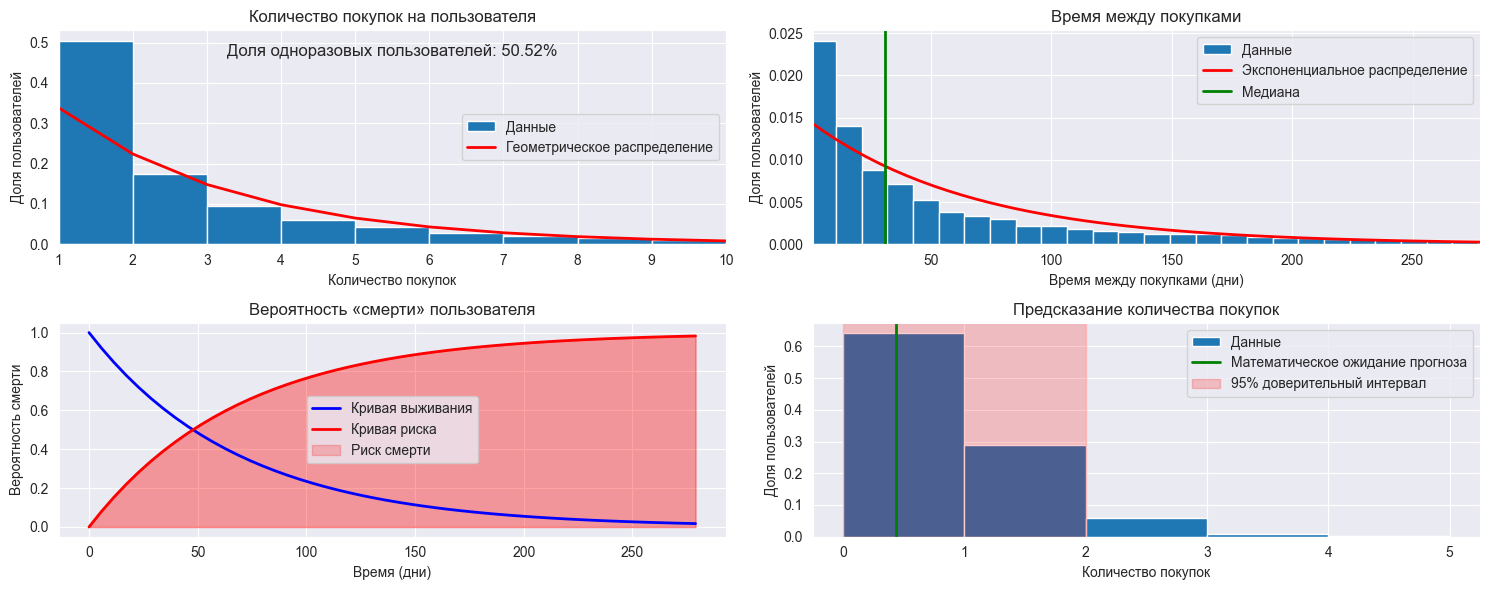

In [5]:
df = pd.read_csv('cdnow.csv', index_col=0)
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values(['customer_id', 'date']).reset_index(drop=True)

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(15, 6))


#Верхний левый
purchases_per_user = df.groupby('customer_id').size()
x = np.arange(1, purchases_per_user.max()+2)
geom_p_est = 1 / purchases_per_user.mean()
geom_density = stats.geom.pmf(x, geom_p_est)

axes[0, 0].hist(purchases_per_user, bins=range(1, purchases_per_user.max()+2), density=True, label = 'Данные')
axes[0, 0].plot(x, geom_density, color='red', lw=2, label = 'Геометрическое распределение')
axes[0,0].set_xlim(1, purchases_per_user.quantile(0.95) + 1)
axes[0, 0].set_title('Количество покупок на пользователя')
axes[0, 0].set_xlabel('Количество покупок')
axes[0, 0].set_ylabel('Доля пользователей')
axes[0, 0].annotate('Доля одноразовых пользователей: {:.2f}%'.format((purchases_per_user == 1).mean() * 100),
                    xy=(0.5, 0.9), xycoords='axes fraction', ha='center', va='center', fontsize=12)
axes[0,0].legend()

#Верхний правый
df['between_days'] = df.groupby('customer_id')['date'].diff().dt.days
intervals = df['between_days'].dropna()
exp_lambda_est = 1 / intervals.mean()
x = np.linspace(0, intervals.quantile(0.95) + 1)
exp_density = stats.expon.pdf(x, scale=1 / exp_lambda_est)
axes[0, 1].hist(intervals, density=True, label = 'Данные', bins=50)
axes[0, 1].plot(x, exp_density, color='red', lw=2, label = 'Экспоненциальное распределение')
axes[0, 1].set_xlim(1, intervals.quantile(0.95))
axes[0, 1].set_title('Время между покупками')
axes[0, 1].set_xlabel('Время между покупками (дни)')
axes[0, 1].set_ylabel('Доля пользователей')
axes[0, 1].axvline(intervals.median(), color='green', lw=2,label = 'Медиана')
axes[0, 1].legend()

#Нижний левый
t = np.linspace(0, intervals.quantile(0.95) + 1)
S = np.exp(-exp_lambda_est * t)
H = 1 - S

axes[1, 0].plot(t, S, color='blue', lw=2, label = 'Кривая выживания')
axes[1, 0].plot(t, H, color='red', lw=2, label = 'Кривая риска')
axes[1, 0].fill_between(t, 0, H, color='red', alpha=0.2)
axes[1, 0].set_title('Вероятность «смерти» пользователя')
axes[1, 0].set_xlabel('Время (дни)')
axes[1, 0].set_ylabel('Вероятность смерти')
axes[1, 0].fill_between(t, 0, H, color='red', alpha=0.2, label = 'Риск смерти')
axes[1, 0].legend()

#Нижний правый
#Сколько x за промежуток t - очевидно, Пуассон. Симулировать будем его.

sim_poisson = np.random.poisson(lam=30 * exp_lambda_est, size=10000)
mean_prediction = 30 * exp_lambda_est
low, high = np.percentile(sim_poisson, [2.5, 97.5])

axes[1, 1].hist(sim_poisson, bins=np.arange(0, max(sim_poisson) + 1), density=True, label = 'Данные')
axes[1, 1].axvline(mean_prediction, color='green', lw=2, label = 'Математическое ожидание прогноза')
axes[1,1].axvspan(low, high, color='red', alpha=0.2, label = '95% доверительный интервал')
axes[1, 1].set_title('Предсказание количества покупок')
axes[1, 1].set_xlabel('Количество покупок')
axes[1, 1].set_ylabel('Доля пользователей')
axes[1, 1].legend()

plt.tight_layout()
plt.show()




**НАПИШИТЕ ВЫВОДЫ ПО ГРАФИКАМ, КОТОРЫЕ БЫ ВЫ СДЕЛАЛИ, КАК АНАЛИТИК (ОТВЕТЫ НА ВОПРОСЫ + РАССУЖДЕНИЯ)**

Представил себя аналитиком в бигтехе. ехала:


### Первый график
Гистограмма показывает, что половина пользователей совершают только одну покупку и больше не возвращаются, около 30% клиентов делают две и более.
Геометрическое распределение в целом повторяет распределение данных, но занижает долю одноразовых пользователей. Это может говорить о том, что удержание клиентов после первого взаимодействия - беда. Нужно сильно поработать над тем, как удерживать клиента после первой покупки: быстрая доставка / подарки?

### Второй график
Медиана между повторными покупками составляет примерно 30 дней. Экспоненциальная модель работает не так хорошо: на 0–20 дней наблюдается более высокая плотность, а в диапазоне 20–150 дней плотность, наоборот, ниже. Похоже, часть клиентов совершают покупки очень часто, тогда как основная масса делает это реже, с более длительными паузами. Тем не менее, экспоненциальное даёт разумную оценку хвоста: редкие, но продолжительные периоды бездействия (более 200 дней) соответствуют модели. Можно попробовать стандартную схему, как отдельно стимулировать и тех, кто много покупает, и тех, кто реже: одним - программы лояльности за частоту, другим - реактивационные скидки.

### Третий график
Кривая риска показывает, что уже через 50 дней без покупок вероятность того, что пользователь больше никогда не вернётся, превышает 50%. К 200 дням эта вероятность достигает почти 90%. Думаю, я бы сделал вывод, что нужно воздействовать на клиента в течение первых периода [10,50] дней, чтобы попытаться его удержать, вернуть.

### Четвёртый график
Симуляция пуассоновского процесса с интенсивностью 30$\lambda$ даёт ожидаемое число покупок на пользователя менее 0.5, т.е. в среднем каждый второй активный клиент совершит одну покупку в месяц. Доверительный интервал показывает, что с высокой вероятностью пользователь купит не более 2 раз, а большинство - 0 или 1. Может, помогут те же программы лояльности, персональные предложения?


чет тухлые какие-то предложения у меня, как будто везде уже и так есть программы лояльности и персональные предложения, не дураки же...

# Бонус с собеса (2+ pt)

Мне понравилась задачка с собеседования, поэтому показываю ее вам:

> На маркетплейсе есть $n$ категорий товаров, в каждой из которых есть $n_i$ различных позиций товаров. Пользователь собирает корзину, делая покупки из любых категорий (может взять из категории, может не взять, может взять из нескольких). Известно, что **средний чек по каждой из категорий** вырос за последний месяц. Что могло произойти с **общим средним чеком**?

Сначала поймите, как считается общий чек. В рассуждениях вы свободны, главное оформите так, чтобы я могла _**понять, где ваш ответ и выводы, на чем они основаны**_. Вы можете делать теоретические выкладки, симуляции и визуализацию. Ничего из этого не запрещено.

Средний чек по категории = общая выручка в этой категории / количество корзин, в которых категория присутствует

Общий средний чек = общая выручка по всем категориям / общее количество корзин.

Думаю, дело в соотношении количества корзин (то есть долей категорий). Если люди, к примеру, стали покупать больше товаров дешёвой категории, и меньше - дорогой, то общий средний чек будет меньше, даже если средний чек каждой категории вырастет. 

*Поискал информацию*

Это парадокс Симпсона! Это кстати именно то, что я встретил в пингвинчиках! Вставлю цитату

> Глубина клюва стала отрицательно коррелировать со всеми остальными признаками (например, с длиной клюва около –0.43).
> Почему так произошло? Причина – в межвидовой изменчивости. Пингвины разных видов систематически различаются по размерам:
> - Gentoo – крупные, с длинными плавниками, большой массой, но мелким клювом.
> - Adelie – мельче, с более короткими плавниками, меньшей массой, но глубоким клювом.
> - Chinstrap – средние.
>При объединении видов основной вклад в разброс вносят именно межвидовые различия, а не внутривидовые. Для глубины клюва направление изменчивости противоположно остальным признакам, поэтому корреляция становится отрицательной.

***Парадокс Симпсона — явление в статистике, при котором при наличии двух групп данных, в каждой из которых наблюдается одинаково направленная зависимость, при объединении этих групп направление зависимости меняется на противоположное.***

Такой ответ был бы сильно коротким, на два балла не тянет, давайте провизуализируем сценарий:

Рассмотрим две категории: «Дорогая» - средний чек 1000, «Дешёвая» - средний чек 100. 
П
усть в прошлом периоде соотношения количества корзин были 0.8 к 0.2 соответственно.
В следующем периоде средние чеки выросли, стали 1100 и 110 соответственно.

Давайте вообще все случаи рассмотрим:
- Соотношение не изменилось
- Соотношение сместилось в сторону «Дорогих» (пусть 0.9 и 0.1)
- Соотношение сместилось в сторону «Дешёвых» (пусть 0.5 и 0.5)
- Соотношение сместилось, но чек не изменился (логично, доля дорогих должна упасть, решим уравнение и поймём)

    w1*1100 + (1-w1)*110 = 820 
    
    w1 = (820-110)/(1100-110) = 710/990. 
    Округлим до 0.7 => стало меньше!

Как будто решение уравнения уже доказывает в частном случае то, что мы показать хотели, но... Визуализируем, чтоб было наглядно круто классно
 
 Мало ли, может мы ошиблись при решении
 
Столбчатые диаграммы выглядят убого, может, просто изобразить зависимость от доли корзин дорогой категории?

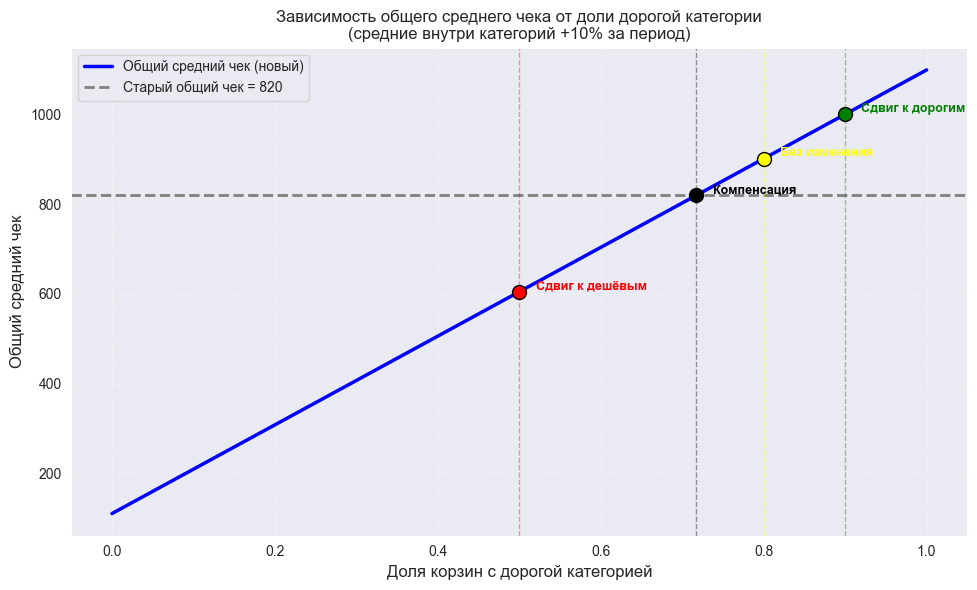

In [6]:
means_old = [1000, 100]
means_new = [1100, 110]
w1_old = 0.8
old_total = w1_old * means_old[0] + (1 - w1_old) * means_old[1]

# Доля дорогой категории
w1 = np.linspace(0, 1, 200)
new_total = w1 * means_new[0] + (1 - w1) * means_new[1]

# Сценарии (вес дорогих)
scenarios = {
    'Без изменения': 0.8,
    'Сдвиг к дорогим': 0.9,
    'Сдвиг к дешёвым': 0.5,
    'Компенсация': 710/990 
}

# Построение
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(w1, new_total, 'b-', lw=2.5, label='Общий средний чек (новый)')
ax.axhline(y=old_total, color='gray', linestyle='--', lw=2, label=f'Старый общий чек = {old_total:.0f}')

colors = ['yellow', 'green', 'red', 'black']
for (name, w_val), col in zip(scenarios.items(), colors):
    y_val = w_val * means_new[0] + (1 - w_val) * means_new[1]
    ax.scatter(w_val, y_val, color=col, s=100, zorder=5, edgecolors='black')
    ax.text(w_val + 0.02, y_val + 5, name, fontsize=9, color=col, weight='bold')
    ax.axvline(x=w_val, color=col, linestyle='--', lw=1, alpha=0.4)

ax.set_xlabel('Доля корзин с дорогой категорией', fontsize=12)
ax.set_ylabel('Общий средний чек', fontsize=12)
ax.set_title('Зависимость общего среднего чека от доли дорогой категории\n(средние внутри категорий +10% за период)')
ax.grid(True, linestyle=':', alpha=0.6)
ax.legend(loc='best')
plt.tight_layout()
plt.show()

Крууууто вообще мне нравится